<a href="https://colab.research.google.com/github/Walnut235/olist-probabilistic-analysis/blob/main/notebooks/01_analisis_olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Probabilístico del E-Commerce Brasileño — Olist

## Machine Learning Probabilístico

**Dataset:** Brazilian E-Commerce Public Dataset by Olist

### Objetivo

Analizar el comportamiento del comercio electrónico de Olist mediante conceptos de probabilidad, estadística e información, con el fin de identificar patrones relevantes para la toma de decisiones.

### Conceptos a estudiar

1. Probabilidad condicional
2. Teorema de Bayes
3. Verosimilitud
4. Máxima verosimilitud (MLE)
5. Distribuciones paramétricas
6. Esperanza y varianza
7. Independencia y correlación
8. Prior y posterior
9. Entropía
10. Entropía cruzada
11. Divergencia KL

# Cargar datos

**Importar librerias**

In [60]:
!pip install -q kagglehub #descargar conexión con kaggle

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub
import os
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

**Descarga del dataset de Olist**

In [62]:

# Descargar el dataset de Olist
dataset_path = kagglehub.dataset_download(
    "olistbr/brazilian-ecommerce"
)

print("Dataset descargado en:")
print(dataset_path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset descargado en:
/kaggle/input/brazilian-ecommerce


**Carga de las tablas**

In [63]:
dataset_path = "/kaggle/input/brazilian-ecommerce"

# Obtener únicamente los archivos CSV
files = [
    file for file in os.listdir(dataset_path)
    if file.endswith(".csv")
]
# Diccionario para almacenar las tablas
data = {}

for file in files:
    file_path = os.path.join(dataset_path, file)

    # Nombre de la tabla sin .csv
    table_name = file.replace(".csv", "")

    # Cargar tabla
    data[table_name] = pd.read_csv(file_path)

print("\nTablas cargadas correctamente:")

for name, df in data.items():
    print(f"{name}: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Tablas cargadas correctamente:
olist_customers_dataset: 99,441 filas × 5 columnas
olist_sellers_dataset: 3,095 filas × 4 columnas
olist_order_reviews_dataset: 99,224 filas × 7 columnas
olist_order_items_dataset: 112,650 filas × 7 columnas
olist_products_dataset: 32,951 filas × 9 columnas
olist_geolocation_dataset: 1,000,163 filas × 5 columnas
product_category_name_translation: 71 filas × 2 columnas
olist_orders_dataset: 99,441 filas × 8 columnas
olist_order_payments_dataset: 103,886 filas × 5 columnas


**Conocer las tablas**

In [64]:
for name, df in data.items(): # recorrer el diccionario
    print(f"\n{'=' * 60}")
    print(name) # nombre de la tabla
    print(f"{'=' * 60}")
    print("Columnas:")

    for column in df.columns: # mostrar las columnas del df
        print(f"  - {column}")



olist_customers_dataset
Columnas:
  - customer_id
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state

olist_sellers_dataset
Columnas:
  - seller_id
  - seller_zip_code_prefix
  - seller_city
  - seller_state

olist_order_reviews_dataset
Columnas:
  - review_id
  - order_id
  - review_score
  - review_comment_title
  - review_comment_message
  - review_creation_date
  - review_answer_timestamp

olist_order_items_dataset
Columnas:
  - order_id
  - order_item_id
  - product_id
  - seller_id
  - shipping_limit_date
  - price
  - freight_value

olist_products_dataset
Columnas:
  - product_id
  - product_category_name
  - product_name_lenght
  - product_description_lenght
  - product_photos_qty
  - product_weight_g
  - product_length_cm
  - product_height_cm
  - product_width_cm

olist_geolocation_dataset
Columnas:
  - geolocation_zip_code_prefix
  - geolocation_lat
  - geolocation_lng
  - geolocation_city
  - geolocation_state

product_category_name_tr

**Verificar relaciones (1:N, 1:1, M:N)**

In [65]:
# ¿Cada customer_id aparece una sola vez?
print("CUSTOMERS")
print("customer_id únicos:", data["olist_customers_dataset"]["customer_id"].nunique())
print("filas:", len(data["olist_customers_dataset"]))

print("\nORDERS")
print("order_id únicos:", data["olist_orders_dataset"]["order_id"].nunique())
print("filas:", len(data["olist_orders_dataset"]))

print("\nPRODUCTS")
print("product_id únicos:", data["olist_products_dataset"]["product_id"].nunique())
print("filas:", len(data["olist_products_dataset"]))

print("\nSELLERS")
print("seller_id únicos:", data["olist_sellers_dataset"]["seller_id"].nunique())
print("filas:", len(data["olist_sellers_dataset"]))

print("\nREVIEWS")
print("order_id únicos:", data["olist_order_reviews_dataset"]["order_id"].nunique())
print("filas:", len(data["olist_order_reviews_dataset"]))

print("\nORDER ITEMS")
print("order_id únicos:", data["olist_order_items_dataset"]["order_id"].nunique())
print("filas:", len(data["olist_order_items_dataset"]))

CUSTOMERS
customer_id únicos: 99441
filas: 99441

ORDERS
order_id únicos: 99441
filas: 99441

PRODUCTS
product_id únicos: 32951
filas: 32951

SELLERS
seller_id únicos: 3095
filas: 3095

REVIEWS
order_id únicos: 98673
filas: 99224

ORDER ITEMS
order_id únicos: 98666
filas: 112650


**Union de las tablas**

In [66]:
# Guardar cada tabla en un df individual
orders = data["olist_orders_dataset"].copy()
customers = data["olist_customers_dataset"].copy()
items = data["olist_order_items_dataset"].copy()
products = data["olist_products_dataset"].copy()
sellers = data["olist_sellers_dataset"].copy()
reviews = data["olist_order_reviews_dataset"].copy()
payments = data["olist_order_payments_dataset"].copy()
geolocation = data["olist_geolocation_dataset"].copy()
category_translation = data["product_category_name_translation"].copy()

In [67]:
df_master = orders.copy()

print("INICIAL")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

INICIAL
Filas: 99441
Pedidos únicos: 99441


In [68]:
df_master = df_master.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one" #Relación 1:1
)

print("DESPUÉS DE CUSTOMERS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE CUSTOMERS
Filas: 99441
Pedidos únicos: 99441


In [69]:
df_master = df_master.merge(
    items,
    on="order_id",
    how="left",
    validate="one_to_many"
)

print("DESPUÉS DE ORDER_ITEMS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE ORDER_ITEMS
Filas: 113425
Pedidos únicos: 99441


In [70]:
df_master = df_master.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("DESPUÉS DE PRODUCTS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE PRODUCTS
Filas: 113425
Pedidos únicos: 99441


In [71]:
df_master = df_master.merge(
    sellers,
    on="seller_id",
    how="left",
    validate="many_to_one"
)

print("DESPUÉS DE SELLERS")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE SELLERS
Filas: 113425
Pedidos únicos: 99441


In [72]:
df_master = df_master.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

print("DESPUÉS DE CATEGORY TRANSLATION")
print("Filas:", len(df_master))
print("Pedidos únicos:", df_master["order_id"].nunique())

DESPUÉS DE CATEGORY TRANSLATION
Filas: 113425
Pedidos únicos: 99441


### Construcción y alcance del DataFrame maestro

Para la construcción del DataFrame maestro se realizaron uniones (`merge`) progresivas tomando como base la tabla `olist_orders_dataset`, donde cada registro representa un pedido. Primero se incorporó la información de los clientes mediante `customer_id` y posteriormente la información de los productos y vendedores a través de `order_items`, utilizando `product_id` y `seller_id`, respectivamente. Finalmente, se incorporó la traducción de las categorías mediante `product_category_name`. Se utilizaron uniones de tipo `left` para conservar los 99.441 pedidos originales, incluso cuando estos no contaban con información asociada en alguna de las tablas. Como resultado, el DataFrame pasó de 99.441 filas a 113.425 debido a que un mismo pedido puede contener varios productos. Las tablas de reseñas (`reviews`) y pagos (`payments`) no se incorporaron directamente al DataFrame maestro, ya que pueden contener múltiples registros asociados a un mismo pedido y podrían alterar su granularidad; estas serán agregadas posteriormente a nivel de `order_id` según las necesidades de cada análisis. La tabla de geolocalización tampoco se incorporó al DataFrame maestro debido a su gran cantidad de registros y a que un mismo código postal puede aparecer múltiples veces. Durante el proyecto, este DataFrame se utilizará como base para los análisis relacionados con pedidos, productos, categorías y vendedores, teniendo siempre en cuenta su granularidad de pedido-producto. Cuando un análisis requiera contar pedidos, clientes u otras entidades, se utilizarán identificadores únicos mediante `nunique()`, y cuando sea necesario obtener variables a nivel de pedido se realizarán las agregaciones correspondientes antes del análisis.

# limpieza de los datos

In [73]:
df_master.head() #Visulizar las 5 primeras filas

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,stationery


**Dejar solo las variables relevantes para el análisis**

In [74]:
variables_master = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_state",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "price",
    "freight_value",
    "seller_id",
    "seller_state",
    "product_category_name",
    "product_weight_g"
]

df_master = df_master[variables_master].copy()

print("Variables seleccionadas:")
print(df_master.columns.tolist())

print("\nDimensiones:")
print(df_master.shape)

Variables seleccionadas:
['order_id', 'customer_id', 'customer_unique_id', 'customer_state', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'price', 'freight_value', 'seller_id', 'seller_state', 'product_category_name', 'product_weight_g']

Dimensiones:
(113425, 14)


In [75]:
print("Columnas con valores faltantes:")
df_master.isna().sum() # Mirar que columnas tienen valores faltantes

Columnas con valores faltantes:


,0
order_id,0
customer_id,0
customer_unique_id,0
customer_state,0
order_status,0
order_purchase_timestamp,0
order_delivered_customer_date,3229
order_estimated_delivery_date,0
price,775
freight_value,775


In [76]:
df_master.dtypes #Mirar tipo de dato por columna

,0
order_id,object
customer_id,object
customer_unique_id,object
customer_state,object
order_status,object
order_purchase_timestamp,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
price,float64
freight_value,float64


**Conversión de tipos de datos (fechas)**

In [77]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_master[col] = pd.to_datetime(df_master[col], errors="coerce") #Convertir columnas de fechas a tipo datetime

print("Tipos de datos después de la conversión:")
print(df_master[date_cols].dtypes)


Tipos de datos después de la conversión:
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Diagnóstico de valores faltantes por `order_status`**

Antes de decidir qué hacer con cada columna con NaN, revisamos si los faltantes están relacionados con el estado del pedido (`order_status`). Esto nos permite distinguir entre un dato *realmente perdido* y un dato que *no existe porque el pedido nunca llegó a esa etapa* (por ejemplo, un pedido cancelado nunca tendrá fecha de entrega).

In [78]:
missing_delivery_orders = (
    df_master[df_master["order_delivered_customer_date"].isna()] # Filtrar los que no tienen fecha de entrega
    .drop_duplicates("order_id") #Trabajar a nivel de cada orden y no de item
)

print("Pedidos únicos sin fecha de entrega:", len(missing_delivery_orders))
print("\nDistribución de order_status:")
print(missing_delivery_orders["order_status"].value_counts())

Pedidos únicos sin fecha de entrega: 2965

Distribución de order_status:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


 El pedido nunca fue entregado (shipped, canceled, unavailable, invoiced, processing) o, en 8 casos, quedó marcado `delivered` sin fecha registrada (inconsistencia del dato original)

In [79]:
missing_items_orders = (
    df_master[df_master["price"].isna()]
    .drop_duplicates("order_id")
)

print("Pedidos únicos sin ítem asociado:", len(missing_items_orders))
print("\nDistribución de order_status:")
print(missing_items_orders["order_status"].value_counts())

Pedidos únicos sin ítem asociado: 775

Distribución de order_status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


 El pedido no tiene ningún ítem asociado en `olist_order_items_dataset`

In [80]:
missing_category = df_master[df_master["product_category_name"].isna()]# analisis de items, filtrar aquellos sin categoria
missing_weight = df_master[df_master["product_weight_g"].isna()]# analisis de items, filtrar aquellos sin peso

print("Filas sin categoría de producto:", len(missing_category))
print("Pedidos únicos afectados por falta de categoria:", missing_category["order_id"].nunique())# número de pedidos con algun item sin categoria
print("\nDistribución de order_status (categoría faltante):")
print(missing_category["order_status"].value_counts())

print("\nFilas sin peso de producto:", len(missing_weight))
print("Pedidos únicos afectados:", missing_weight["order_id"].nunique())# número de pedidos con algun item sin peso

Filas sin categoría de producto: 2378
Pedidos únicos afectados por falta de categoria: 2226

Distribución de order_status (categoría faltante):
order_status
delivered      1537
unavailable     603
canceled        178
shipped          28
invoiced         14
processing       13
created           5
Name: count, dtype: int64

Filas sin peso de producto: 793
Pedidos únicos afectados: 791


Inconsistencia conocida del dataset original de Olist, hay productos (`product_id`) sin categoría registrada en `olist_products_dataset`.Lo mismo pasa en el caso de los pesos de los productos.

**Tratamiento de valores faltantes**

No aplicamos `dropna()` global. Cada columna con NaN se trata según **por qué** falta el dato:

| Columna | NaN | Tratamiento |
|---|---|---|
| `order_delivered_customer_date` | 3.229 filas / 2.965 pedidos |  **Se conserva como NaN.** No se imputa una fecha inventada. Se usa para construir la variable derivada `retrasado`, que quedará en `NaN` quan no se pueda determinar. |
| `price`, `freight_value`, `seller_id`, `seller_state` | 775 filas | **Se conservan como NaN.** Estas filas se excluyen puntualmente solo en los análisis que dependen de precio/flete/vendedor (ej. esperanza y varianza del ticket, independencia pago–categoría), no se eliminan del DataFrame completo. |
| `product_category_name` | 2.378 filas | **Se imputa con la etiqueta `"sin_categoria"`** en lugar de NaN, para que estos productos sí cuenten como una categoría propia en los análisis de entropía e independencia (ignorarlos silenciosamente subestimaría la diversidad real del catálogo). |
| `product_weight_g` | 793 filas |  **Se conserva como NaN** y se excluye únicamente del análisis de distribución paramétrica del peso (no se imputa un peso, porque inventar un valor numérico sí distorsionaría el ajuste de la distribución). |

Ningún pedido se elimina del DataFrame por tener NaN en estas columnas — solo se excluye puntualmente de los análisis específicos que requieren esa variable.

In [81]:
df_clean = df_master.copy()

# Imputación puntual de product_category_name
df_clean["product_category_name"] = df_clean["product_category_name"].fillna("sin_categoria")#imputar "Sin categoria" cuando esta haga falta, a nivel de item

print("df_clean creado.")
print("Filas:", len(df_clean))
print("Columnas:", len(df_clean.columns))
print("\nValores faltantes restantes:")
print(df_clean.isna().sum())

df_clean creado.
Filas: 113425
Columnas: 14

Valores faltantes restantes:
order_id                            0
customer_id                         0
customer_unique_id                  0
customer_state                      0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    3229
order_estimated_delivery_date       0
price                             775
freight_value                     775
seller_id                         775
seller_state                      775
product_category_name               0
product_weight_g                  793
dtype: int64


**Variable derivada: `retrasado`**

Regla (ya definida): solo se clasifica un pedido como retrasado / no retrasado si fue efectivamente **entregado** y tiene fecha real de entrega. En cualquier otro caso, `retrasado = NaN` (no sabemos, no inventamos).

In [82]:
# Filas que tienen fecha de entrega pero NO están en estado delivered
inconsistencias = df_clean[
    df_clean["order_delivered_customer_date"].notna() &
    (df_clean["order_status"] != "delivered")
]

print("Filas con fecha de entrega pero estado diferente de 'delivered':", len(inconsistencias))

if len(inconsistencias) == 0:
    print("✓ Todos los registros con fecha de entrega pertenecen a pedidos 'delivered'.")
else:
    print("\nEstados encontrados:")
    print(inconsistencias["order_status"].value_counts())

Filas con fecha de entrega pero estado diferente de 'delivered': 7

Estados encontrados:
order_status
canceled    7
Name: count, dtype: int64


Estos registros fueron cancelados, pero aun así tienen una fecha de entrega registrada, lo cual representa una inconsistencia. A falta de información sobre su causa exacta, existen dos explicaciones plausibles: (1) un error de registro en la fecha, o (2) un fenómeno real, en el que el pedido llegó a entregarse (o inició su proceso logístico) y solo después fue cancelado en el sistema.

Como no es posible distinguir entre ambos escenarios con la información disponible, no se sobrescribe order_status ni se asume que la fecha implica una entrega real. Estos pedidos se conservan tal como están y, en consecuencia, quedan fuera de la clasificación de retrasado (NaN), igual que el resto de pedidos no entregados. Esta inconsistencia se documenta como limitación conocida del dataset, junto con los 8 casos delivered sin fecha.

In [83]:
fue_entregado = (
    (df_clean["order_status"] == "delivered") &
    (df_clean["order_delivered_customer_date"].notna())#asi se excluyen los registros que fueron entregados pero no tienen fecha de entrega registrada
)

df_clean["retrasado"] = np.where(
    fue_entregado, #¿pertenece a fue entregado?
    (df_clean["order_delivered_customer_date"] > df_clean["order_estimated_delivery_date"]).astype(int),
    np.nan #de lo contrario NaN
)

print("Distribución de 'retrasado' (incluye NaN = no clasificable):")
print(df_clean["retrasado"].value_counts(dropna=False))

print("\nPedidos únicos clasificables:", df_clean.loc[df_clean["retrasado"].notna(), "order_id"].nunique())

Distribución de 'retrasado' (incluye NaN = no clasificable):
retrasado
0.0    101475
1.0      8714
NaN      3236
Name: count, dtype: int64

Pedidos únicos clasificables: 96470


**Validaciones de consistencia**

In [84]:
print("1) Precios y fletes negativos:")
print("   price < 0:", (df_clean["price"] < 0).sum())
print("   freight_value < 0:", (df_clean["freight_value"] < 0).sum())

print("\n2) Consistencia cronológica (compra <= entrega, cuando hay fecha real):")
inconsistentes = df_clean[
    df_clean["order_delivered_customer_date"].notna() &
    (df_clean["order_delivered_customer_date"] < df_clean["order_purchase_timestamp"])
]
print("   Pedidos con fecha de entrega ANTES de la compra:", inconsistentes["order_id"].nunique())

print("\n3) Rango de fechas del dataset:")
print("   Compra: ", df_clean["order_purchase_timestamp"].min(), "→", df_clean["order_purchase_timestamp"].max())

1) Precios y fletes negativos:
   price < 0: 0
   freight_value < 0: 0

2) Consistencia cronológica (compra <= entrega, cuando hay fecha real):
   Pedidos con fecha de entrega ANTES de la compra: 0

3) Rango de fechas del dataset:
   Compra:  2016-09-04 21:15:19 → 2018-10-17 17:30:18


# Concepto 1 — Probabilidad condicional

**Pregunta de negocio:** ¿La demora en la entrega se asocia con reseñas negativas?

In [85]:
reviews = data["olist_order_reviews_dataset"]

# Número de reseñas y puntuaciones diferentes por pedido
reviews_por_pedido = (
    reviews
    .groupby("order_id")
    .agg(
        num_reseñas=("review_id", "count"),
        num_puntuaciones=("review_score", "nunique")
    )
)

# Pedidos con más de una reseña
multiples_reseñas = reviews_por_pedido[
    reviews_por_pedido["num_reseñas"] > 1
]

print("Pedidos con múltiples reseñas:", len(multiples_reseñas))

print(
    "Pedidos con múltiples reseñas y puntuaciones diferentes:",
    (multiples_reseñas["num_puntuaciones"] > 1).sum()
)

print("\nDistribución del número de reseñas por pedido:")
print(multiples_reseñas["num_reseñas"].value_counts().sort_index())

print("\nPedidos con puntuaciones diferentes:")
print(
    multiples_reseñas[
        multiples_reseñas["num_puntuaciones"] > 1
    ]
)

Pedidos con múltiples reseñas: 547
Pedidos con múltiples reseñas y puntuaciones diferentes: 202

Distribución del número de reseñas por pedido:
num_reseñas
2    543
3      4
Name: count, dtype: int64

Pedidos con puntuaciones diferentes:
                                  num_reseñas  num_puntuaciones
order_id                                                       
013056cfe49763c6f66bda03396c5ee3            2                 2
02355020fd0a40a0d56df9f6ff060413            2                 2
029863af4b968de1e5d6a82782e662f5            2                 2
03c939fd7fd3b38f8485a0f95798f1f6            3                 2
03eba6d9fef8f5b3e811d4b5a7cca9cd            2                 2
...                                       ...               ...
fa350da9efbba83c2957b629bf6c2c7c            2                 2
fc3d87913825143fa41c48e40267c47a            2                 2
fcde2f7449493b4f207a23fae117b0fb            2                 2
fd61441ba2a7b57e6342862e779b10b0            2             

**Tratamiento de múltiples reseñas**: Se identificaron 547 pedidos con más de una reseña, de los cuales 202 presentan puntuaciones diferentes entre sus reseñas. Debido a que estos casos representan una proporción muy pequeña del conjunto de pedidos, se conservaron todas las reseñas disponibles para el análisis probabilístico. Por tanto, la unidad de análisis para la probabilidad condicional será la reseña, asociando a cada una las características del pedido correspondiente. Esta decisión permite conservar la información disponible sin seleccionar arbitrariamente una única reseña por pedido. Los resultados se interpretarán como probabilidades asociadas a reseñas y no directamente como probabilidades asociadas a pedidos.

**Crear un dataset que incluya las reseñas**

In [86]:
orders_analysis = (
    df_clean[
        [
            "order_id",
            "order_delivered_customer_date",  #incluir las caracteristicas necesarias para el analisis
            "order_estimated_delivery_date"
        ]
    ]
    .drop_duplicates("order_id") #Dejar solo un order_id para evitar duplicar reseñas al hacer el merge
)

orders_analysis["tardio"] = (
    orders_analysis["order_delivered_customer_date"]  #calcular si una orden llego tarde comparando la fecha de entrega con la fecha estimada de entrega
    > orders_analysis["order_estimated_delivery_date"]
)

reviews_analysis = (
    data["olist_order_reviews_dataset"][
        ["review_id", "order_id", "review_score"] #Unir los datasets para obtener uno que incluya las reseñas
    ]
    .merge(
        orders_analysis,
        on="order_id",
        how="inner"
    )
)

reviews_analysis["reseña_negativa"] = (
    reviews_analysis["review_score"] <= 2  #Identificar las reseñas negativas en una columna boleana
)

grupo_tardio = reviews_analysis[
    reviews_analysis["tardio"]
]

p_tardio_y_negativa =  (
    reviews_analysis["tardio"] &
    reviews_analysis["reseña_negativa"]
).mean()

p_tardio = reviews_analysis["tardio"].mean() # número de

p_negativa_dado_tardio = p_tardio_y_negativa / p_tardio

print("Numerador:", p_tardio_y_negativa)
print("Denominador:", p_tardio)

print(
    f"P(reseña < 2 | pedido tardío) = {p_negativa_dado_tardio:.4f}"
)

print(
    f"Porcentaje = {p_negativa_dado_tardio * 100:.2f}%"
)
print("Reseñas asociadas a pedidos tardíos:", len(grupo_tardio))

print(
    "Reseñas menores a 2 estrellas:",
    grupo_tardio["reseña_negativa"].sum()
)

print(
    "Pedidos únicos representados:",
    reviews_analysis["order_id"].nunique()
)

Numerador: 0.041925340643392726
Denominador: 0.0776122712247037
P(reseña < 2 | pedido tardío) = 0.5402
Porcentaje = 54.02%
Reseñas asociadas a pedidos tardíos: 7701
Reseñas menores a 2 estrellas: 4160
Pedidos únicos representados: 98673


La probabilidad de que una reseña tenga una puntuación menor o igual a 2 sabiendo que la orden a la que esta asociada llego con tardanza es de 0.5402.

Esto significa que aproximadamente el 54% de las reseñas asociadas a pedidos que llegaron tarde presentan una puntuación de 2 estrellas o menos.

# Concepto 2 — Teorema de Bayes

**Pregunta de negocio:** Si un pedido recibió una reseña negativa, ¿qué tan probable es que haya llegado tarde?

Ya calculamos en el punto anterior: $$P(reseña negativa∣pedido tardío)=0.5402$$
Ahora usando bayes podemos obtener $$P(pedido tardío∣reseña negativa)$$
Usando la fórmula: $$P(tardío|negativa) = \frac{P(negativa|tardío)P(tardío)}{P(negativa)}$$

In [87]:
p_negativa = reviews_analysis["reseña_negativa"].mean()
p_tardio_dado_negativa = (
    p_negativa_dado_tardio * p_tardio
) / p_negativa

print(f"P(negativa | tardío): {p_negativa_dado_tardio:.4f}")
print(f"P(tardío): {p_tardio:.4f}")
print(f"P(negativa): {p_negativa:.4f}")
print(f"P(tardío ∩ negativa): {p_tardio_y_negativa:.4f}")
print(f"P(tardío | negativa): {p_tardio_dado_negativa:.4f}")

P(negativa | tardío): 0.5402
P(tardío): 0.0776
P(negativa): 0.1469
P(tardío ∩ negativa): 0.0419
P(tardío | negativa): 0.2854


Utilizando el teorema de bayes se llego a que la probabilidad de que un pedido sea tardio dado que tuvo un puntaje en la reseña menor o igual a 2 es de 0.2854

# Concepto 3 — Verosimilitud / MLE

**Pregunta de negocio:** ¿Qué distribución de probabilidad describe mejor el tiempo de entrega, y qué tan bien se ajusta frente a una alternativa?

In [88]:
df_clean["tiempo_entrega_dias"] = (     #calcular el tiempo de entrega
    df_clean["order_delivered_customer_date"] -
    df_clean["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)



**Ajustar las distribuciones propuestas**

In [93]:
x = df_clean["tiempo_entrega_dias"].values

x_clean = x[np.isfinite(x)]# Filtrar solo los valores finitos (elimina NaN e inf)

lognorm_params = stats.lognorm.fit(x_clean, floc=0)# Ajustar los parámetros de la distribución
print("Parámetros Log-Normal:")
print("sigma =", lognorm_params[0])
print("loc   =", lognorm_params[1])
print("scale =", lognorm_params[2])

Parámetros Log-Normal:
sigma = 0.6792084028065883
loc   = 0
scale = 9.978475467921022


In [94]:
gamma_params = stats.gamma.fit(x_clean, floc=0)

print("Parámetros Gamma:")
print("shape =", gamma_params[0])
print("loc   =", gamma_params[1])
print("scale =", gamma_params[2])

Parámetros Gamma:
shape = 2.3945423095861877
loc   = 0
scale = 5.208774338385863


**Evaluar los dos ajustes**

In [96]:
loglik_lognorm = np.sum(
    stats.lognorm.logpdf(x_clean, *lognorm_params)
)

loglik_gamma = np.sum(
    stats.gamma.logpdf(x_clean, *gamma_params)
)

n = len(x_clean)

k_lognorm = len(lognorm_params)
k_gamma = len(gamma_params)

aic_lognorm = 2*k_lognorm - 2*loglik_lognorm
aic_gamma = 2*k_gamma - 2*loglik_gamma

bic_lognorm = k_lognorm*np.log(n) - 2*loglik_lognorm
bic_gamma = k_gamma*np.log(n) - 2*loglik_gamma

print("Log-Normal")
print("Log-Likelihood:", loglik_lognorm)
print("AIC:", aic_lognorm)
print("BIC:", bic_lognorm)

print("\nGamma")
print("Log-Likelihood:", loglik_gamma)
print("AIC:", aic_gamma)
print("BIC:", bic_gamma)

Log-Normal
Log-Likelihood: -367232.7520263466
AIC: 734471.5040526933
BIC: 734500.3341003255

Gamma
Log-Likelihood: -369334.95012702927
AIC: 738675.9002540585
BIC: 738704.7303016908


**Visualizar las distribuciones propuestas frente a los datos**

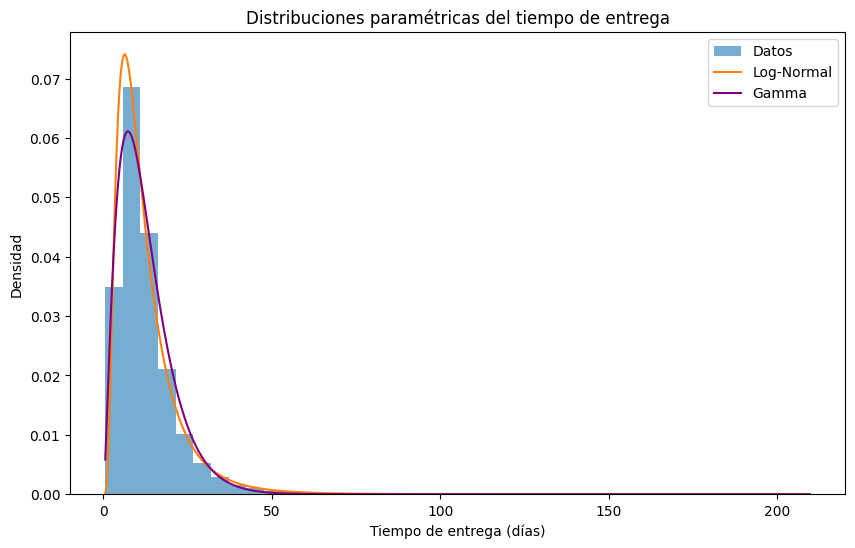

In [101]:
plt.figure(figsize=(10,6))

plt.hist(
    x_clean,
    bins=40,
    density=True,
    alpha=0.6,
    label="Datos"
)

x_grid = np.linspace(x_clean.min(), x_clean.max(), 500)

plt.plot(
    x_grid,
    stats.lognorm.pdf(x_grid, *lognorm_params),
    label="Log-Normal"
)

plt.plot(
    x_grid,
    stats.gamma.pdf(x_grid, *gamma_params),
    label="Gamma",
    color="purple"
)

plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Densidad")
plt.title("Distribuciones paramétricas del tiempo de entrega")
plt.legend()
plt.show()

# Concepto 4 — Distribuciones paramétricas

**Pregunta de negocio:** ¿Qué distribución paramétrica describe mejor el peso de los paquetes o el valor de los pedidos, y qué evidencia respalda esa elección?

In [102]:
df_clean

,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,seller_id,seller_state,product_category_name,product_weight_g,retrasado,tiempo_entrega_dias
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,SP,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,SP,utilidades_domesticas,500.0,0.0,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,BA,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,SP,perfumaria,400.0,0.0,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,GO,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,SP,automotivo,420.0,0.0,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,RN,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,45.00,27.20,66922902710d126a0e7d26b0e3805106,MG,pet_shop,450.0,0.0,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,SP,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,19.90,8.72,2c9e548be18521d1c43cde1c582c6de8,SP,papelaria,250.0,0.0,2.873877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,da62f9e57a76d978d02ab5362c509660,SP,delivered,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02,174.90,20.10,1f9ab4708f3056ede07124aad39a2554,SP,bebes,4950.0,0.0,22.193727
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,737520a9aad80b3fbbdad19b66b37b30,BA,delivered,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27,205.99,65.02,d50d79cb34e38265a8649c383dcffd48,SP,eletrodomesticos_2,13300.0,0.0,24.859421
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,RJ,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,179.99,40.59,a1043bafd471dff536d0c462352beb48,MG,informatica_acessorios,6550.0,0.0,17.086424
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,RJ,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,179.99,40.59,a1043bafd471dff536d0c462352beb48,MG,informatica_acessorios,6550.0,0.0,17.086424


In [110]:
x=df_clean["product_weight_g"]

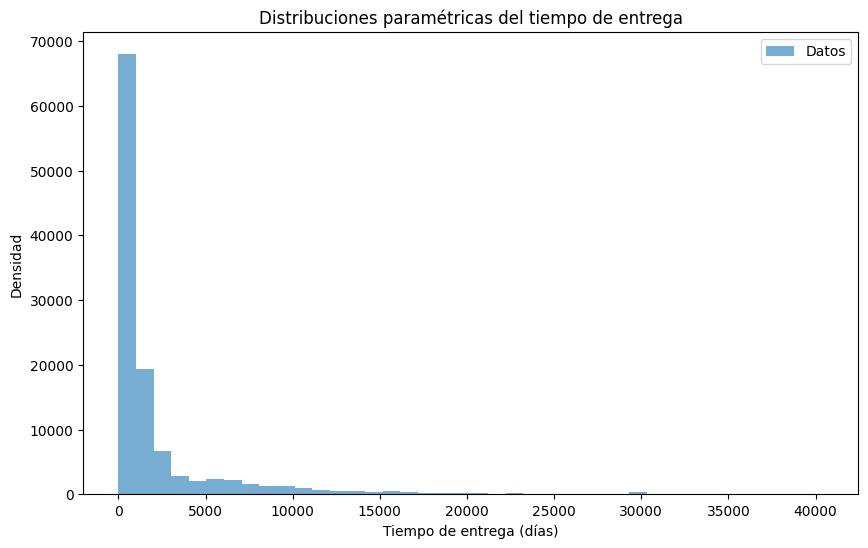

In [107]:
plt.figure(figsize=(10,6))

plt.hist(
    x,
    bins=40,
    alpha=0.6,
    label="Datos"
)

x_grid = np.linspace(x.min(), x.max(), 500)

plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Densidad")
plt.title("Distribuciones paramétricas del tiempo de entrega")
plt.legend()
plt.show()

# Concepto 5 — Esperanza y varianza

**Pregunta de negocio:** ¿Cuál es el ticket promedio por categoría de producto, y en cuáles hay mayor variabilidad (riesgo)?

**Calcular el valor total del item (precio + flete)**

In [126]:
df_clean["valor_item"] = (
    df_clean["price"] +
    df_clean["freight_value"]
)

In [141]:
category_stats = (
    df_clean
    .groupby("product_category_name")["valor_item"] #obtener estadisticas por categoria
    .agg(
        esperanza="mean",
        varianza="var",
        desviacion="std",
        observaciones="count"
    )
    .sort_values("esperanza", ascending=False) #ordenar de mayor a menor varianza
)

category_stats.head(10)

,esperanza,varianza,desviacion,observaciones
product_category_name,,,,
pcs,1146.795222,457812.432072,676.618380,203
portateis_casa_forno_e_cafe,660.441711,390426.210217,624.840948,76
eletrodomesticos_2,520.663529,312471.187273,558.991223,238
agro_industria_e_comercio,369.689009,188230.115570,433.854948,212
instrumentos_musicais,309.025544,214665.607160,463.320199,680
eletroportateis,304.372356,232788.474371,482.481579,679
portateis_cozinha_e_preparadores_de_alimentos,285.219333,179009.193178,423.094780,15
telefonia_fixa,243.260644,181003.011259,425.444487,264
construcao_ferramentas_seguranca,229.193918,104668.491713,323.525102,194


# Concepto 6 — Independencia y correlación

**Pregunta de negocio:** ¿El método de pago y la categoría de producto son variables independientes? ¿Existe correlación entre el tiempo de entrega y la calificación del cliente?

# Concepto 7 — Prior y posterior

**Pregunta de negocio:** ¿Cómo se puede estimar la confiabilidad de un vendedor nuevo, partiendo de un prior poblacional y actualizándolo con la evidencia de sus primeras ventas?

# Concepto 8 — Entropía

**Pregunta de negocio:** ¿Qué tan diversa o concentrada es la distribución de categorías de producto (o de métodos de pago) en el catálogo de Olist?

# Concepto 9 — Entropía cruzada

**Pregunta de negocio:** ¿Qué tan bien puede un modelo simple predecir si una reseña será positiva o negativa a partir de las variables del pedido?

# Concepto 10 — Divergencia KL

**Pregunta de negocio:** ¿Qué tan diferente es la percepción de calidad (distribución de calificaciones) entre dos estados de Brasil o dos categorías de producto?